# CcaSR-GFP Control: Reproducing Figures 3 & 4

Reproduces figures 3 and 4 from:
> *Control of a bi-stable genetic system via parallelised RL*, Lugagne Lab, CDC 2025

**Figure 3** — Strategy comparison: Random | Bang-Bang | PI | PQN  
**Figure 4** — PQN scaling with number of parallel environments (fixed total budget)

**Prerequisites**: Run `./run.sh` from this directory first to populate `outputs/` with
the baseline evaluations and the PQN training run.

**Known differences vs paper**:
- Paper uses linear LR annealing (`lr_linear_decay=true`); Myriad uses fixed RAdam.
- `epsilon_decay_steps` is in update-step units (2197 = 0.3 × ⌊29297÷4⌋) matching the
  paper's `eps_decay=0.3` fraction-of-updates definition.
- Figure 3's PQN bar uses the final training-eval checkpoint (16 rollouts). For a
  higher-fidelity estimate, increase `eval_rollouts` in `configs/pqn.yaml` and re-run.

## §0 Setup

In [1]:
import os
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from myriad.configs.builder import create_config, create_eval_config
from myriad.platform import (
    EvaluationResults,
    TrainingResults,
    evaluate,
    load_run,
    load_run_metadata,
    load_run_results,
    train_and_evaluate,
)

print(f"JAX devices: {jax.devices()}")

OUTPUTS_DIR = Path("outputs")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

JAX devices: [CudaDevice(id=0)]


In [2]:
def find_runs(outputs_dir: Path, agent_name: str | None = None) -> list[Path]:
    """Scan outputs/ for run directories, optionally filtering by agent name."""
    runs = []
    for run_path in sorted(outputs_dir.glob("*/*")):
        if not (run_path / "run_metadata.yaml").exists():
            continue
        if agent_name is not None:
            try:
                results = load_run_results(run_path)
                if results.config.agent.name != agent_name:
                    continue
            except Exception:
                continue
        runs.append(run_path)
    return runs


def find_latest_run(outputs_dir: Path, agent_name: str) -> Path | None:
    """Return the most recent run for a given agent (by directory sort order)."""
    runs = find_runs(outputs_dir, agent_name)
    return runs[-1] if runs else None

## §1 Load Baseline Results

Load evaluation results from `./run.sh` for random, bang-bang, and PI controllers.

In [3]:
baseline_agents = ["random", "bangbang", "pid"]
baseline_results: dict[str, EvaluationResults] = {}

for agent in baseline_agents:
    run_path = find_latest_run(OUTPUTS_DIR, agent)
    if run_path is None:
        print(f"[!] No run found for agent '{agent}'. Run ./run.sh first.")
        continue
    results = load_run_results(run_path)
    baseline_results[agent] = results
    print(f"{agent:>10}: mean_return={results.mean_return:.1f} ± {results.std_return:.1f}")

    random: mean_return=-5376.4 ± 573.3
  bangbang: mean_return=-3037.7 ± 806.3
       pid: mean_return=-2784.4 ± 557.9


## §2 PQN Final Eval Metrics

Load the PQN training results from `results.pkl` and read the final eval metrics
(16 rollouts, recorded at the last eval checkpoint during training).

> **Note**: Checkpoint serialization for Flax structs is not yet supported, so we
> cannot run a post-hoc 1000-rollout eval. The 16-rollout estimate from training is
> used instead. For a higher-fidelity number, increase `eval_rollouts` in
> `configs/pqn.yaml` before running `./run.sh`.

In [4]:
pqn_run_path = find_latest_run(OUTPUTS_DIR, "pqn")

if pqn_run_path is None:
    print("[!] No PQN training run found. Run `./run.sh` first.")
    pqn_final_mean = pqn_final_std = None
else:
    pqn_results = load_run_results(pqn_run_path)
    eval_means = pqn_results.eval_metrics.mean_return
    eval_stds = pqn_results.eval_metrics.std_return
    if not eval_means:
        print("[!] PQN results found but eval_metrics is empty.")
        pqn_final_mean = pqn_final_std = None
    else:
        pqn_final_mean = eval_means[-1]
        pqn_final_std = eval_stds[-1]
        print(f"PQN final eval ({pqn_results.config.run.eval_rollouts} rollouts): "
              f"{pqn_final_mean:.1f} ± {pqn_final_std:.1f}")

PQN final eval (16 rollouts): -3159.5 ± 658.2


## §3 Figure 3 — Strategy Comparison (Paper Table II)

Bar chart comparing mean episode return across all control strategies.
Expected ranking: Random < Bang-Bang ≈ PI ≤ PQN.

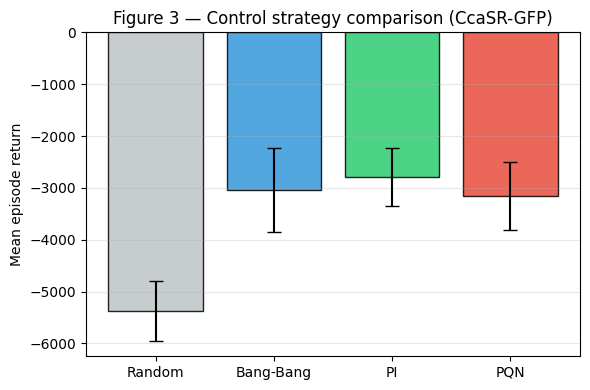


Table II equivalents:
      Random: -5376.4 ± 573.3
   Bang-Bang: -3037.7 ± 806.3
          PI: -2784.4 ± 557.9
         PQN: -3159.5 ± 658.2


In [5]:
# --- Assemble data for fig3 ---
strategy_display = {
    "random": "Random",
    "bangbang": "Bang-Bang",
    "pid": "PI",
    "pqn": "PQN",
}

fig3_means: dict[str, float] = {}
fig3_stds: dict[str, float] = {}

for agent, res in baseline_results.items():
    fig3_means[agent] = res.mean_return
    fig3_stds[agent] = res.std_return

if pqn_final_mean is not None:
    fig3_means["pqn"] = pqn_final_mean
    fig3_stds["pqn"] = pqn_final_std

labels = [strategy_display[k] for k in fig3_means]
means = list(fig3_means.values())
stds = list(fig3_stds.values())
colors = ["#bdc3c7", "#3498db", "#2ecc71", "#e74c3c"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, means, yerr=stds, capsize=5, color=colors[: len(labels)], alpha=0.85, edgecolor="k")
ax.set_ylabel("Mean episode return")
ax.set_title("Figure 3 — Control strategy comparison (CcaSR-GFP)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig3_strategy_comparison.pdf")
plt.show()

print("\nTable II equivalents:")
for agent, label in strategy_display.items():
    if agent in fig3_means:
        print(f"  {label:>10}: {fig3_means[agent]:7.1f} ± {fig3_stds[agent]:.1f}")

## §4 Figure 4 — PQN Scaling with num_envs (Paper Table III)

Fixed total timesteps = 30M, vary `num_envs` ∈ {8, 32, 128, 512, 1024}.
Each run uses the same training budget; more envs = more parallelism, fewer steps per env.

**Runtime note**: This cell trains 5 PQN agents back-to-back (~10 min each on an RTX 5090
for small num_envs). Expect ~30–90 min total. Run once and re-load from disk on repeat.

Minimum `num_envs=8` satisfies the minibatch constraint:
`minibatch_size = num_envs × rollout_steps / num_minibatches = 8×4/8 = 4 ≥ 1`. ✓

In [ ]:
TOTAL_TIMESTEPS = 30_000_000
NUM_ENVS_SWEEP = [8, 32, 128, 512, 1024]

scaling_results: dict[int, dict] = {}  # num_envs → {mean, std}

for num_envs in NUM_ENVS_SWEEP:
    steps_per_env = TOTAL_TIMESTEPS // num_envs
    print(f"\n--- num_envs={num_envs}, steps_per_env={steps_per_env:,} ---")

    config = create_config(
        env="ccasr-gfp-control",
        agent="pqn",
        num_envs=num_envs,
        steps_per_env=steps_per_env,
        rollout_steps=4,
        eval_rollouts=16,
        eval_max_steps=288,
        eval_frequency=max(4, steps_per_env // 100),  # ~1% of training, div by rollout_steps
        seed=42,
        wandb_enabled=False,
        # Agent params (matching pqn.yaml)
        learning_rate=1e-4,
        lambda_=0.3,
        reward_scale=0.1,
        epsilon_decay_fraction=0.3,  # resolved to epsilon_decay_steps = 0.3 × steps_per_env
        epsilon_end=0.005,
        hidden_size=512,
        num_layers=3,
        num_epochs=4,
        num_minibatches=8,
        # Env: 16-frame stacking
        **{"env.frame_stack_n": 16},
    )

    r = train_and_evaluate(config)
    print(r)

    # Post-training eval: 1000 rollouts for a reliable estimate
    eval_config = create_eval_config(
        env="ccasr-gfp-control",
        agent="pqn",
        eval_rollouts=1000,
        eval_max_steps=288,
        seed=42,
        **{"env.frame_stack_n": 16},
    )
    final_eval = evaluate(eval_config, agent_state=r.agent_state)
    scaling_results[num_envs] = {
        "mean": final_eval.mean_return,
        "std": final_eval.std_return,
    }
    print(f"  final eval (1000 eps): {final_eval.mean_return:.1f} ± {final_eval.std_return:.1f}")

In [ ]:
# --- Figure 4 plot ---
x = list(scaling_results.keys())
y_mean = [scaling_results[n]["mean"] for n in x]
y_std = [scaling_results[n]["std"] for n in x]

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(x, y_mean, yerr=y_std, marker="o", capsize=5, color="#e74c3c", linewidth=2)
ax.set_xscale("log")
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in x])
ax.set_xlabel("Number of parallel environments (num_envs)")
ax.set_ylabel("Mean episode return (1000 rollouts)")
ax.set_title(f"Figure 4 — PQN scaling (fixed total budget = {TOTAL_TIMESTEPS:,} steps)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig4_scaling.pdf")
plt.show()

print("\nTable III equivalents (Paper: return should increase with num_envs):")
for n in x:
    print(f"  num_envs={n:>5}: {scaling_results[n]['mean']:7.1f} ± {scaling_results[n]['std']:.1f}")